# Notebook 5 — Expert Review Pack and Interpretation

This notebook is the final notebook in the **main thesis-core series**.

It:
- reloads the cleaned claim tables and tuned model outputs
- rebuilds the final clean scoring pipeline for **unlabeled claim triage**
- uses the chosen operating point for expert review:
  - assumed anomaly-rate setting: **3%**
  - main ensemble method: **majority vote**
  - main single-model comparator: **OC-SVM**
- prepares a **blinded mixed-case expert review pack**
- exports internal and expert-facing files
- optionally analyzes expert ratings after completed review files are returned

## Expert-review design
The notebook creates three case groups:
1. **Ensemble-top cases**
2. **Single-model-only cases**
3. **Low-score control cases**

The expert-facing packet hides the group/source labels.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Cell 1 - Load libraries and project paths
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.svm import OneClassSVM

THESIS_ROOT = Path('/content/drive/MyDrive/NyanThesisAnomaly')

with open(THESIS_ROOT / 'project_paths.json', 'r', encoding='utf-8') as f:
    PROJECT_PATHS = json.load(f)

DATA_PROCESSED_DIR = Path(PROJECT_PATHS['DATA_PROCESSED_DIR'])
TABLES_DIR = Path(PROJECT_PATHS['TABLES_DIR'])
FIGURES_DIR = Path(PROJECT_PATHS['FIGURES_DIR'])
FILES_DIR = Path(PROJECT_PATHS['FILES_DIR'])
NOTEBOOK_EXPORTS_DIR = Path(PROJECT_PATHS['NOTEBOOK_EXPORTS_DIR'])
PHASE1_DIR = Path(PROJECT_PATHS['PHASE1_DIR'])
PHASE2_DIR = Path(PROJECT_PATHS['PHASE2_DIR'])
PHASE3_DIR = Path(PROJECT_PATHS['PHASE3_DIR'])

ANALYTICAL_PATH = DATA_PROCESSED_DIR / 'claims_analytical_table_v1.parquet'
MODEL_FEATURES_PATH = DATA_PROCESSED_DIR / 'claims_model_features_v1.parquet'
TRAIN_KEYS_PATH = PHASE1_DIR / '03_train_claim_keys.csv'
VAL_KEYS_PATH = PHASE1_DIR / '03_validation_claim_keys.csv'
TEST_KEYS_PATH = PHASE1_DIR / '03_test_claim_keys.csv'
BEST_CONFIGS_PATH = PHASE2_DIR / '04_best_configs.csv'
ENSEMBLE_METRICS_PATH = PHASE2_DIR / '04_ensemble_metrics.csv'
TUNED_METRICS_PATH = PHASE2_DIR / '04_tuned_model_metrics.csv'

print('Phase 3 output dir:', PHASE3_DIR)


Phase 3 output dir: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review


In [3]:
#Cell 2 - Load processed data, split files, and tuned model metadata
claims_analytical = pd.read_parquet(ANALYTICAL_PATH)
model_features = pd.read_parquet(MODEL_FEATURES_PATH)

train_keys = pd.read_csv(TRAIN_KEYS_PATH)['CLAIM_KEY'].astype(str)
val_keys = pd.read_csv(VAL_KEYS_PATH)['CLAIM_KEY'].astype(str)
test_keys = pd.read_csv(TEST_KEYS_PATH)['CLAIM_KEY'].astype(str)

best_configs = pd.read_csv(BEST_CONFIGS_PATH)
ensemble_metrics = pd.read_csv(ENSEMBLE_METRICS_PATH)
tuned_metrics = pd.read_csv(TUNED_METRICS_PATH)

print('Analytical shape:', claims_analytical.shape)
print('Model feature shape:', model_features.shape)
print('Best-config rows:', len(best_configs))

display(best_configs)


Analytical shape: (175005, 103)
Model feature shape: (175005, 23)
Best-config rows: 9


,assumed_rate,model,param_index,params_json,average_precision,roc_auc,precision_at_k,recall_at_k
0,0.01,iforest,5,"{""max_samples"": 0.8, ""n_estimators"": 200}",0.124020,0.931044,0.174905,0.174905
1,0.01,lof,1,"{""n_neighbors"": 15}",0.394098,0.957103,0.425856,0.425856
2,0.01,ocsvm,4,"{""gamma"": 0.1, ""nu"": 0.03}",0.390581,0.967801,0.501901,0.501901
3,0.03,iforest,5,"{""max_samples"": 0.8, ""n_estimators"": 200}",0.300458,0.932898,0.404822,0.404822
4,0.03,lof,1,"{""n_neighbors"": 15}",0.630818,0.951411,0.645939,0.645939
5,0.03,ocsvm,4,"{""gamma"": 0.1, ""nu"": 0.03}",0.624320,0.969619,0.662437,0.662437
6,0.05,iforest,5,"{""max_samples"": 0.8, ""n_estimators"": 200}",0.433593,0.937745,0.505712,0.505712
7,0.05,lof,1,"{""n_neighbors"": 15}",0.720943,0.957407,0.712871,0.712871
8,0.05,ocsvm,4,"{""gamma"": 0.1, ""nu"": 0.03}",0.703244,0.967309,0.674029,0.674029


In [4]:
#Cell 3 - Set the expert-review operating point and sample sizes
OPERATING_RATE = 0.03
PRIMARY_ENSEMBLE = 'majority_vote'
PRIMARY_SINGLE_MODEL = 'ocsvm'

N_ENSEMBLE_CASES = 20
N_SINGLE_ONLY_CASES = 20
N_CONTROL_CASES = 20

RANDOM_STATE = 42

print('Operating rate:', OPERATING_RATE)
print('Primary ensemble:', PRIMARY_ENSEMBLE)
print('Primary single model comparator:', PRIMARY_SINGLE_MODEL)
print('Review sample sizes:', N_ENSEMBLE_CASES, N_SINGLE_ONLY_CASES, N_CONTROL_CASES)


Operating rate: 0.03
Primary ensemble: majority_vote
Primary single model comparator: ocsvm
Review sample sizes: 20 20 20


In [5]:
#Cell 4 - Rebuild the merged clean modeling table
merged = model_features.merge(
    claims_analytical,
    on='CLAIM_KEY',
    how='left',
    suffixes=('_model', '')
)

merged['CLAIM_KEY'] = merged['CLAIM_KEY'].astype(str)

train_df = merged[merged['CLAIM_KEY'].isin(train_keys)].copy()
val_df = merged[merged['CLAIM_KEY'].isin(val_keys)].copy()
test_df = merged[merged['CLAIM_KEY'].isin(test_keys)].copy()
all_clean_df = merged.copy()

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test', 'all_clean'],
    'n_rows': [len(train_df), len(val_df), len(test_df), len(all_clean_df)]
})

display(split_summary)


,split,n_rows
0,train,122503
1,validation,26251
2,test,26251
3,all_clean,175005


In [6]:
#Cell 5 - Rebuild train-based rarity features and cyclical time features
def build_frequency_map(series):
    clean = series.dropna().astype(str)
    if clean.empty:
        return {}
    return clean.value_counts(normalize=True).to_dict()

diag_freq_map = build_frequency_map(train_df['primary_diag_code'])
proc_freq_map = build_frequency_map(train_df['primary_proc_code'])
hcpcs_freq_map = build_frequency_map(train_df['primary_hcpcs_code'])

pair_series = (
    train_df['primary_diag_code'].astype('string').fillna('MISSING')
    + '||' +
    train_df['primary_hcpcs_code'].astype('string').fillna('MISSING')
)
pair_freq_map = pair_series.value_counts(normalize=True).to_dict()

def add_rarity_features(frame):
    out = frame.copy()

    out['primary_diag_freq_train'] = out['primary_diag_code'].astype('string').map(diag_freq_map).fillna(0.0)
    out['primary_proc_freq_train'] = out['primary_proc_code'].astype('string').map(proc_freq_map).fillna(0.0)
    out['primary_hcpcs_freq_train'] = out['primary_hcpcs_code'].astype('string').map(hcpcs_freq_map).fillna(0.0)

    pair_key = (
        out['primary_diag_code'].astype('string').fillna('MISSING')
        + '||' +
        out['primary_hcpcs_code'].astype('string').fillna('MISSING')
    )
    out['diag_hcpcs_pair_freq_train'] = pair_key.map(pair_freq_map).fillna(0.0)

    out['rare_primary_diag_flag'] = (out['primary_diag_freq_train'] <= 0.001).astype('int8')
    out['rare_primary_proc_flag'] = (out['primary_proc_freq_train'] <= 0.001).astype('int8')
    out['rare_primary_hcpcs_flag'] = (out['primary_hcpcs_freq_train'] <= 0.001).astype('int8')
    out['rare_diag_hcpcs_pair_flag'] = (out['diag_hcpcs_pair_freq_train'] <= 0.0005).astype('int8')
    return out

def add_cyclical_time_features(frame):
    out = frame.copy()
    out['claim_from_month_sin'] = np.sin(2 * np.pi * out['claim_from_month'].fillna(0) / 12)
    out['claim_from_month_cos'] = np.cos(2 * np.pi * out['claim_from_month'].fillna(0) / 12)
    out['claim_from_dayofweek_sin'] = np.sin(2 * np.pi * out['claim_from_dayofweek'].fillna(0) / 7)
    out['claim_from_dayofweek_cos'] = np.cos(2 * np.pi * out['claim_from_dayofweek'].fillna(0) / 7)
    return out

train_df = add_cyclical_time_features(add_rarity_features(train_df))
all_clean_df = add_cyclical_time_features(add_rarity_features(all_clean_df))

display(all_clean_df[['primary_diag_freq_train', 'primary_hcpcs_freq_train', 'diag_hcpcs_pair_freq_train']].head())


,primary_diag_freq_train,primary_hcpcs_freq_train,diag_hcpcs_pair_freq_train
0,0.000408,0.022288,0.000196
1,0.000498,0.000259,0.000008
2,0.000098,0.029033,0.000008
3,0.000090,0.000000,0.000033
4,0.000188,0.252862,0.000008


In [7]:
#Cell 6 - Rebuild the final feature matrix and train-only scaler
FINAL_FEATURE_COLS = [
    'CLM_PMT_AMT',
    'NCH_PRMRY_PYR_CLM_PD_AMT',
    'total_beneficiary_liability',
    'claim_duration_days',
    'claim_from_month',
    'claim_from_dayofweek',
    'claim_from_day',
    'is_weekend_claim',
    'is_same_day_claim',
    'diag_code_count',
    'proc_code_count',
    'hcpcs_code_count',
    'has_admitting_diag',
    'has_any_diag',
    'has_any_proc',
    'has_any_hcpcs',
    'zero_payment_flag',
    'log_clm_pmt_amt',
    'log_primary_payer_amt',
    'log_total_bene_liability',
    'high_cost_flag_p95',
    'extreme_cost_flag_p99',
    'primary_diag_freq_train',
    'primary_proc_freq_train',
    'primary_hcpcs_freq_train',
    'diag_hcpcs_pair_freq_train',
    'rare_primary_diag_flag',
    'rare_primary_proc_flag',
    'rare_primary_hcpcs_flag',
    'rare_diag_hcpcs_pair_flag',
    'claim_from_month_sin',
    'claim_from_month_cos',
    'claim_from_dayofweek_sin',
    'claim_from_dayofweek_cos',
]

train_medians = train_df[FINAL_FEATURE_COLS].median(numeric_only=True)

def prepare_numeric_features(frame, scaler=None, fit_scaler=False):
    X = frame[FINAL_FEATURE_COLS].copy().fillna(train_medians)

    if fit_scaler:
        scaler = RobustScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = scaler.transform(X)

    X_scaled = pd.DataFrame(X_scaled, columns=FINAL_FEATURE_COLS, index=frame.index)
    return X, X_scaled, scaler

X_train_raw, X_train_scaled, scaler = prepare_numeric_features(train_df, fit_scaler=True)
X_all_raw, X_all_scaled, _ = prepare_numeric_features(all_clean_df, scaler=scaler, fit_scaler=False)

MAX_FINAL_TRAIN_ROWS = 30000
if len(X_train_scaled) > MAX_FINAL_TRAIN_ROWS:
    final_train_idx = train_df.sample(n=MAX_FINAL_TRAIN_ROWS, random_state=RANDOM_STATE).index
else:
    final_train_idx = train_df.index

X_train_final = X_train_scaled.loc[final_train_idx].copy()

print('Training rows used for final clean scoring:', len(X_train_final))
print('All clean rows to score:', len(X_all_scaled))


Training rows used for final clean scoring: 30000
All clean rows to score: 175005


In [8]:
#Cell 7 - Fit tuned models at the 3% operating point and score all clean claims
rate_best = best_configs[best_configs['assumed_rate'] == OPERATING_RATE].copy()

def build_model(model_name, rate, params):
    if model_name == 'iforest':
        return IsolationForest(
            n_estimators=params['n_estimators'],
            max_samples=params['max_samples'],
            contamination=rate,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if model_name == 'lof':
        return LocalOutlierFactor(
            n_neighbors=params['n_neighbors'],
            contamination=rate,
            novelty=True,
        )
    if model_name == 'ocsvm':
        return OneClassSVM(
            kernel='rbf',
            nu=params['nu'],
            gamma=params['gamma'],
        )
    raise ValueError(f'Unknown model name: {model_name}')

def get_anomaly_scores(model, X):
    if hasattr(model, 'score_samples'):
        scores = -model.score_samples(X)
    else:
        scores = -model.decision_function(X)
    return np.asarray(scores)

clean_scores = pd.DataFrame({'CLAIM_KEY': all_clean_df['CLAIM_KEY'].astype(str)})

for _, cfg in rate_best.iterrows():
    model_name = cfg['model']
    params = json.loads(cfg['params_json'])
    model = build_model(model_name, OPERATING_RATE, params)
    model.fit(X_train_final)
    clean_scores[model_name] = get_anomaly_scores(model, X_all_scaled)

display(clean_scores.head())


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


,CLAIM_KEY,iforest,lof,ocsvm
0,542372281246633_1,0.391717,1.074291,-1.520481
1,542702280893497_1,0.394533,1.004993,-1.551105
2,542712281107503_1,0.414917,1.173596,-1.496669
3,542912281339207_1,0.446671,1.087033,-1.431886
4,542862281135179_1,0.422840,1.078888,-1.360164


In [9]:
#Cell 8 - Build ensemble scores and clean triage flags
def percentile_rank_scores(scores):
    s = pd.Series(scores)
    return s.rank(method='average', pct=True).to_numpy()

for model_name in ['iforest', 'lof', 'ocsvm']:
    clean_scores[f'{model_name}_pct_rank'] = percentile_rank_scores(clean_scores[model_name].to_numpy())

clean_scores['ensemble_rank_mean'] = clean_scores[[f'{m}_pct_rank' for m in ['iforest', 'lof', 'ocsvm']]].mean(axis=1)

for model_name in ['iforest', 'lof', 'ocsvm']:
    threshold = np.quantile(clean_scores[model_name], 1 - OPERATING_RATE)
    clean_scores[f'{model_name}_topflag'] = (clean_scores[model_name] >= threshold).astype(int)

clean_scores['ensemble_vote_count'] = clean_scores[[f'{m}_topflag' for m in ['iforest', 'lof', 'ocsvm']]].sum(axis=1)
clean_scores['ensemble_majority_vote_score'] = clean_scores['ensemble_vote_count'] / 3
clean_scores['ensemble_majority_flag'] = (clean_scores['ensemble_vote_count'] >= 2).astype(int)

score_summary = pd.DataFrame({
    'metric': ['n_clean_claims', 'n_majority_flagged', 'n_iforest_flagged', 'n_lof_flagged', 'n_ocsvm_flagged'],
    'value': [
        len(clean_scores),
        int(clean_scores['ensemble_majority_flag'].sum()),
        int(clean_scores['iforest_topflag'].sum()),
        int(clean_scores['lof_topflag'].sum()),
        int(clean_scores['ocsvm_topflag'].sum()),
    ]
})

display(score_summary)


,metric,value
0,n_clean_claims,175005
1,n_majority_flagged,3452
2,n_iforest_flagged,5251
3,n_lof_flagged,5251
4,n_ocsvm_flagged,5251


In [10]:
#Cell 9 - Merge clean scores back to claim context and compute descriptive percentiles
review_base = all_clean_df.merge(clean_scores, on='CLAIM_KEY', how='left', validate='one_to_one').copy()

for col in ['CLM_PMT_AMT', 'total_beneficiary_liability', 'claim_duration_days', 'diag_code_count', 'proc_code_count', 'hcpcs_code_count']:
    rank_col = f'{col}_pctile'
    review_base[rank_col] = review_base[col].rank(method='average', pct=True)

review_base['low_diag_hcpcs_pair_freq_flag'] = (review_base['diag_hcpcs_pair_freq_train'] <= review_base['diag_hcpcs_pair_freq_train'].quantile(0.01)).astype(int)

display(review_base[[
    'CLAIM_KEY', 'ensemble_vote_count', 'ensemble_rank_mean', 'ocsvm',
    'CLM_PMT_AMT_pctile', 'claim_duration_days_pctile', 'hcpcs_code_count_pctile'
]].head())


,CLAIM_KEY,ensemble_vote_count,ensemble_rank_mean,ocsvm,CLM_PMT_AMT_pctile,claim_duration_days_pctile,hcpcs_code_count_pctile
0,542372281246633_1,0,0.374414,-1.520481,0.273886,0.439073,0.438256
1,542702280893497_1,0,0.216049,-1.551105,0.334230,0.439073,0.191146
2,542712281107503_1,0,0.584568,-1.496669,0.559575,0.439073,0.591177
3,542912281339207_1,0,0.660779,-1.431886,0.789077,0.439073,0.942736
4,542862281135179_1,0,0.642113,-1.360164,0.725334,0.439073,0.191146


In [11]:
#Cell 10 - Select the blinded expert-review sample
ensemble_top = (
    review_base[review_base['ensemble_majority_flag'] == 1]
    .sort_values(['ensemble_vote_count', 'ensemble_rank_mean'], ascending=[False, False])
    .head(N_ENSEMBLE_CASES)
    .copy()
)
ensemble_top['review_group_internal'] = 'ensemble_top'

exclude_keys = set(ensemble_top['CLAIM_KEY'].astype(str))

single_only_candidates = review_base[
    (~review_base['CLAIM_KEY'].astype(str).isin(exclude_keys)) &
    (review_base['ocsvm_topflag'] == 1)
].copy()

single_only = (
    single_only_candidates
    .sort_values(['ocsvm', 'ensemble_rank_mean'], ascending=[False, False])
    .head(N_SINGLE_ONLY_CASES)
    .copy()
)
single_only['review_group_internal'] = 'single_model_only'

exclude_keys.update(single_only['CLAIM_KEY'].astype(str))

low_score_pool = review_base[
    (~review_base['CLAIM_KEY'].astype(str).isin(exclude_keys)) &
    (review_base['ensemble_rank_mean'] <= review_base['ensemble_rank_mean'].quantile(0.50)) &
    (review_base['ocsvm_topflag'] == 0) &
    (review_base['lof_topflag'] == 0) &
    (review_base['iforest_topflag'] == 0)
].copy()

control_cases = low_score_pool.sample(n=N_CONTROL_CASES, random_state=RANDOM_STATE).copy()
control_cases['review_group_internal'] = 'control_low_score'

review_sample = pd.concat([ensemble_top, single_only, control_cases], ignore_index=True)
review_sample = review_sample.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
review_sample['REVIEW_CASE_ID'] = [f'CASE_{i:03d}' for i in range(1, len(review_sample) + 1)]

group_counts = review_sample['review_group_internal'].value_counts().reset_index()
group_counts.columns = ['review_group_internal', 'n_cases']

display(group_counts)


,review_group_internal,n_cases
0,ensemble_top,20
1,single_model_only,20
2,control_low_score,20


In [12]:
#Cell 11 - Create concise expert-facing explanations for each case
def pct_text(x):
    if pd.isna(x):
        return 'missing'
    return f'{int(round(float(x) * 100))}th percentile'

def build_explanation(row):
    signals = []

    if pd.notna(row.get('CLM_PMT_AMT_pctile')) and row['CLM_PMT_AMT_pctile'] >= 0.95:
        signals.append(f'claim payment is at the {pct_text(row["CLM_PMT_AMT_pctile"])}')
    if pd.notna(row.get('total_beneficiary_liability_pctile')) and row['total_beneficiary_liability_pctile'] >= 0.95:
        signals.append(f'beneficiary liability is at the {pct_text(row["total_beneficiary_liability_pctile"])}')
    if pd.notna(row.get('claim_duration_days_pctile')) and row['claim_duration_days_pctile'] >= 0.95:
        signals.append(f'claim duration is unusually high at the {pct_text(row["claim_duration_days_pctile"])}')
    if pd.notna(row.get('hcpcs_code_count_pctile')) and row['hcpcs_code_count_pctile'] >= 0.95:
        signals.append(f'HCPCS code count is at the {pct_text(row["hcpcs_code_count_pctile"])}')
    if int(row.get('is_weekend_claim', 0)) == 1:
        signals.append('service timing falls on a weekend')
    if int(row.get('rare_primary_hcpcs_flag', 0)) == 1 or int(row.get('rare_diag_hcpcs_pair_flag', 0)) == 1:
        signals.append('primary code pattern appears rare relative to the training distribution')
    if int(row.get('zero_payment_flag', 0)) == 1:
        signals.append('claim has zero or non-positive payment')

    if not signals:
        signals.append('case is high-ranked by anomaly scoring relative to peer claims')

    return '; '.join(signals[:3])

review_sample['short_explanation'] = review_sample.apply(build_explanation, axis=1)

review_sample['claim_date'] = pd.to_datetime(review_sample['CLM_FROM_DT'], errors='coerce').dt.strftime('%Y-%m-%d')
review_sample['claim_payment_rounded'] = review_sample['CLM_PMT_AMT'].round(2)
review_sample['bene_liability_rounded'] = review_sample['total_beneficiary_liability'].round(2)

display(review_sample[['REVIEW_CASE_ID', 'review_group_internal', 'short_explanation']].head())


,REVIEW_CASE_ID,review_group_internal,short_explanation
0,CASE_001,ensemble_top,claim payment is at the 99th percentile; prima...
1,CASE_002,ensemble_top,primary code pattern appears rare relative to ...
2,CASE_003,single_model_only,service timing falls on a weekend
3,CASE_004,control_low_score,primary code pattern appears rare relative to ...
4,CASE_005,ensemble_top,claim payment is at the 97th percentile; servi...


In [13]:
#Cell 12 - Export internal mapping, blinded expert packet, and rating templates
internal_review_path = PHASE3_DIR / '05_internal_review_mapping.csv'
blinded_packet_csv_path = PHASE3_DIR / '05_expert_packet_blinded.csv'
blinded_packet_xlsx_path = PHASE3_DIR / '05_expert_packet_blinded.xlsx'
template_csv_path = PHASE3_DIR / '05_expert_rating_template.csv'
template_xlsx_path = PHASE3_DIR / '05_expert_rating_workbook.xlsx'

internal_cols = [
    'REVIEW_CASE_ID', 'CLAIM_KEY', 'review_group_internal',
    'ensemble_vote_count', 'ensemble_rank_mean', 'iforest', 'lof', 'ocsvm'
]
review_sample[internal_cols].to_csv(internal_review_path, index=False)

expert_packet_cols = [
    'REVIEW_CASE_ID',
    'claim_date',
    'claim_payment_rounded',
    'bene_liability_rounded',
    'claim_duration_days',
    'diag_code_count',
    'proc_code_count',
    'hcpcs_code_count',
    'is_weekend_claim',
    'zero_payment_flag',
    'primary_diag_code',
    'primary_proc_code',
    'primary_hcpcs_code',
    'short_explanation',
]
expert_packet = review_sample[expert_packet_cols].copy()
expert_packet.to_csv(blinded_packet_csv_path, index=False)

rating_template = expert_packet[['REVIEW_CASE_ID']].copy()
rating_template['expert_id'] = ''
rating_template['suspiciousness_1to5'] = ''
rating_template['actionability_1to5'] = ''
rating_template['plausibility_1to5'] = ''
rating_template['interpretability_1to5'] = ''
rating_template['optional_notes'] = ''
rating_template.to_csv(template_csv_path, index=False)

instructions_df = pd.DataFrame({
    'instruction': [
        'Use a 1 to 5 scale for each rating item.',
        '1 = very low, 5 = very high.',
        'Suspiciousness: how unusual or concerning the claim appears.',
        'Actionability: whether the case seems worth further review or audit.',
        'Plausibility: whether the flagged pattern appears coherent and believable.',
        'Interpretability: whether the explanation is understandable enough for review.',
        'Do not try to infer which model generated the case.',
    ]
})

with pd.ExcelWriter(blinded_packet_xlsx_path, engine='openpyxl') as writer:
    expert_packet.to_excel(writer, sheet_name='case_packet_blinded', index=False)

with pd.ExcelWriter(template_xlsx_path, engine='openpyxl') as writer:
    instructions_df.to_excel(writer, sheet_name='instructions', index=False)
    expert_packet.to_excel(writer, sheet_name='case_packet_blinded', index=False)
    rating_template.to_excel(writer, sheet_name='rating_template_blank', index=False)
    for expert_label in ['E1', 'E2', 'E3', 'E4', 'E5']:
        temp = rating_template.copy()
        temp['expert_id'] = expert_label
        temp.to_excel(writer, sheet_name=f'ratings_{expert_label}', index=False)

print('Saved internal mapping to:', internal_review_path)
print('Saved blinded packet CSV to:', blinded_packet_csv_path)
print('Saved blinded packet XLSX to:', blinded_packet_xlsx_path)
print('Saved rating template CSV to:', template_csv_path)
print('Saved rating workbook XLSX to:', template_xlsx_path)


Saved internal mapping to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review/05_internal_review_mapping.csv
Saved blinded packet CSV to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review/05_expert_packet_blinded.csv
Saved blinded packet XLSX to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review/05_expert_packet_blinded.xlsx
Saved rating template CSV to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review/05_expert_rating_template.csv
Saved rating workbook XLSX to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review/05_expert_rating_workbook.xlsx


In [14]:
#Cell 13 - Save clean triage rankings for documentation and later reuse
clean_ranking_cols = [
    'CLAIM_KEY', 'ensemble_vote_count', 'ensemble_rank_mean', 'ensemble_majority_flag',
    'iforest', 'lof', 'ocsvm',
    'iforest_topflag', 'lof_topflag', 'ocsvm_topflag'
]

clean_ranking_path = PHASE3_DIR / '05_clean_claim_rankings.csv'
review_base[clean_ranking_cols].sort_values(['ensemble_vote_count', 'ensemble_rank_mean'], ascending=[False, False]).to_csv(clean_ranking_path, index=False)

print('Saved clean claim ranking file to:', clean_ranking_path)


Saved clean claim ranking file to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review/05_clean_claim_rankings.csv


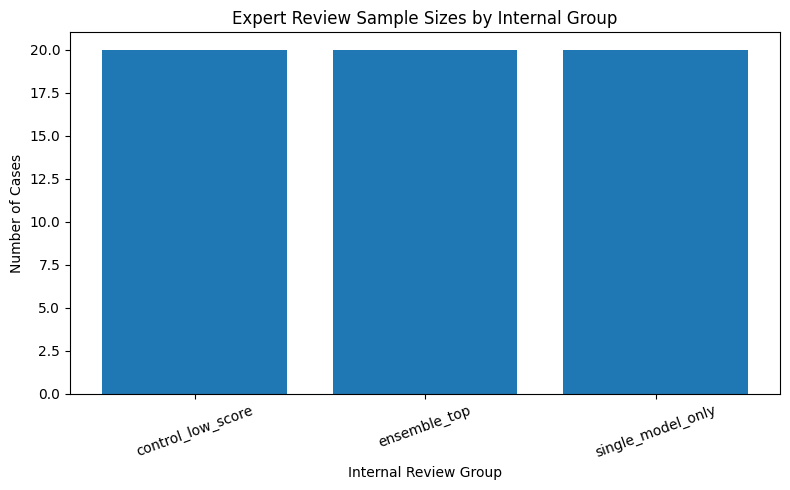

Saved figure to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/figures/05_review_sample_group_counts.png


In [15]:
#Cell 14 - Plot the review-sample group counts
group_count_series = review_sample['review_group_internal'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(group_count_series.index, group_count_series.values)
plt.title('Expert Review Sample Sizes by Internal Group')
plt.xlabel('Internal Review Group')
plt.ylabel('Number of Cases')
plt.xticks(rotation=20)
plt.tight_layout()

fig_group_counts_path = FIGURES_DIR / '05_review_sample_group_counts.png'
plt.savefig(fig_group_counts_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved figure to:', fig_group_counts_path)


In [16]:
#Cell 15 - Load completed expert ratings if available
ratings_csv_path = PHASE3_DIR / '05_expert_ratings_combined.csv'
ratings_xlsx_path = PHASE3_DIR / '05_expert_ratings_completed.xlsx'

ratings_loaded = False
ratings_long = None

if ratings_csv_path.exists():
    ratings_long = pd.read_csv(ratings_csv_path)
    ratings_loaded = True
    print('Loaded expert ratings CSV:', ratings_csv_path)

elif ratings_xlsx_path.exists():
    xls = pd.ExcelFile(ratings_xlsx_path)
    rating_sheets = [s for s in xls.sheet_names if s.startswith('ratings_')]
    parts = []
    for sheet in rating_sheets:
        part = pd.read_excel(ratings_xlsx_path, sheet_name=sheet)
        if {'REVIEW_CASE_ID', 'expert_id'}.issubset(part.columns):
            parts.append(part)
    if parts:
        ratings_long = pd.concat(parts, ignore_index=True)
        ratings_loaded = True
        print('Loaded expert ratings workbook:', ratings_xlsx_path)

if ratings_loaded:
    print('Ratings shape:', ratings_long.shape)
    display(ratings_long.head())
else:
    print('No completed expert-rating file found yet.')
    print('After expert review is finished, place either:')
    print('-', ratings_csv_path)
    print('-', ratings_xlsx_path)
    print('Then rerun Cells 15 onward.')


No completed expert-rating file found yet.
After expert review is finished, place either:
- /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review/05_expert_ratings_combined.csv
- /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review/05_expert_ratings_completed.xlsx
Then rerun Cells 15 onward.


In [17]:
#Cell 16 - Merge completed ratings with internal review groups and clean the rating fields
if ratings_loaded:
    rating_cols = ['suspiciousness_1to5', 'actionability_1to5', 'plausibility_1to5', 'interpretability_1to5']

    for col in rating_cols:
        ratings_long[col] = pd.to_numeric(ratings_long[col], errors='coerce')

    ratings_merged = ratings_long.merge(
        review_sample[['REVIEW_CASE_ID', 'review_group_internal']],
        on='REVIEW_CASE_ID',
        how='left',
        validate='many_to_one'
    )

    print('Merged ratings shape:', ratings_merged.shape)
    display(ratings_merged.head())
else:
    ratings_merged = None


In [18]:
#Cell 17 - Summarize expert ratings by group and item
if ratings_loaded:
    rating_cols = ['suspiciousness_1to5', 'actionability_1to5', 'plausibility_1to5', 'interpretability_1to5']

    summary_rows = []
    for group_name, group_df in ratings_merged.groupby('review_group_internal'):
        for col in rating_cols:
            vals = group_df[col].dropna()
            summary_rows.append({
                'review_group_internal': group_name,
                'rating_item': col,
                'n_ratings': int(vals.shape[0]),
                'mean_rating': float(vals.mean()) if len(vals) else np.nan,
                'median_rating': float(vals.median()) if len(vals) else np.nan,
                'pct_high_rating_ge4': float((vals >= 4).mean()) if len(vals) else np.nan,
            })

    expert_summary = pd.DataFrame(summary_rows)
    expert_summary_path = PHASE3_DIR / '05_expert_rating_summary.csv'
    expert_summary.to_csv(expert_summary_path, index=False)

    display(expert_summary.sort_values(['rating_item', 'mean_rating'], ascending=[True, False]))
    print('Saved expert rating summary to:', expert_summary_path)
else:
    expert_summary = None


In [19]:
#Cell 18 - Create expert-rating comparison figures when completed ratings are available
if ratings_loaded:
    for item in ['suspiciousness_1to5', 'actionability_1to5', 'plausibility_1to5', 'interpretability_1to5']:
        temp = expert_summary[expert_summary['rating_item'] == item].copy().sort_values('mean_rating', ascending=False)

        plt.figure(figsize=(8, 5))
        plt.bar(temp['review_group_internal'], temp['mean_rating'])
        plt.title(f'Mean Expert Rating by Group: {item}')
        plt.xlabel('Internal Review Group')
        plt.ylabel('Mean Rating')
        plt.xticks(rotation=20)
        plt.tight_layout()

        out_path = FIGURES_DIR / f'05_{item}_by_group.png'
        plt.savefig(out_path, dpi=200, bbox_inches='tight')
        plt.show()

        print('Saved figure to:', out_path)
else:
    print('No ratings loaded yet. Skipping expert-rating figures.')


No ratings loaded yet. Skipping expert-rating figures.


In [20]:
#Cell 19 - Export notebook run summary
run_summary = {
    'operating_rate': OPERATING_RATE,
    'primary_ensemble': PRIMARY_ENSEMBLE,
    'primary_single_model': PRIMARY_SINGLE_MODEL,
    'internal_review_path': str(internal_review_path),
    'blinded_packet_csv_path': str(blinded_packet_csv_path),
    'blinded_packet_xlsx_path': str(blinded_packet_xlsx_path),
    'template_csv_path': str(template_csv_path),
    'template_xlsx_path': str(template_xlsx_path),
    'clean_ranking_path': str(clean_ranking_path),
    'group_count_figure_path': str(fig_group_counts_path),
}

run_summary_path = NOTEBOOK_EXPORTS_DIR / '05_expert_review_run_summary.json'
with open(run_summary_path, 'w', encoding='utf-8') as f:
    json.dump(run_summary, f, indent=2)

print('Saved run summary to:', run_summary_path)
print(json.dumps(run_summary, indent=2))


Saved run summary to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/notebook_exports/05_expert_review_run_summary.json
{
  "operating_rate": 0.03,
  "primary_ensemble": "majority_vote",
  "primary_single_model": "ocsvm",
  "internal_review_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review/05_internal_review_mapping.csv",
  "blinded_packet_csv_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review/05_expert_packet_blinded.csv",
  "blinded_packet_xlsx_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review/05_expert_packet_blinded.xlsx",
  "template_csv_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review/05_expert_rating_template.csv",
  "template_xlsx_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review/05_expert_rating_workbook.xlsx",
  "clean_ranking_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase3_expert_review/05_clean_claim_rankings.csv",
  "